Задания:
 1. Проверьте условия проведения A/B тестирования:<br>
    1.1 Примерное равенство групп.<br>
    1.2 Отсутствие дубликатов.<br>
    1.3 Пользователь не может принадлежать двум группам.<br>
 2. Удалите выбросы.
 3. Создайте отчет, содержащий метрики:
        total_orders
        total_revenue
        unique_users
        ARPU
        AOV
 4. Проверьте гипотезу о равенстве выручки в двух группах.
 5. Сформилируйте вывод по отчету и тесту.

### Загрузка и обработка данных

In [550]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st
import random

In [551]:
df = pd.read_csv('ab.csv')

In [552]:
df.columns = df.columns.str.lower()

### 1. Проверка условия проведения A/B тестирования

#### 1.1 Равны ли группы

In [553]:
# Общее число пользователей
n = df['user_id'].nunique()
n

6324

In [554]:
# Распределение пользователей по группам
df.groupby('variant_name')['user_id'].nunique() / n * 100

variant_name
control    62.160025
variant    62.207464
Name: user_id, dtype: float64

#### 1.3 Принадлежат ли пользователи двум группам

In [555]:
a = set(df.query('variant_name == "control"')['user_id'].unique())

In [556]:
b = set(df.query('variant_name == "variant"')['user_id'].unique())

In [557]:
a_b = a & b
len(a_b)

1541

In [558]:
# Как распределены пользователи без них - примерно одинаково
print(len(a - a_b), len(b - a_b))

2390 2393


In [559]:
# Следовательно, распределим группу пользователей, находящихся одновременно в двух группах, поровну в variant и control случайным образом
groups = ['variant', 'control']

for user_id in a_b:
    df_user_id = df.query('user_id == @user_id')['variant_name']
    df.loc[df_user_id.index, 'variant_name'] = random.choice(groups)

In [560]:
# Вновь проверим распределение пользователей по группам
df.groupby('variant_name')['user_id'].nunique() / n * 100

variant_name
control    50.411132
variant    49.588868
Name: user_id, dtype: float64

In [561]:
(df.groupby('variant_name')['user_id'].nunique() / n * 100).sum()

np.float64(100.0)

#### 1.2 Отсутствуют ли дубликаты

In [562]:
df.duplicated().sum()

np.int64(24)

In [563]:
df[df.duplicated(keep=False)].sort_values('user_id').head()

,user_id,variant_name,revenue
1712,578,variant,2.79
7855,578,variant,2.79
5232,688,variant,1.12
9696,688,variant,1.12
7512,757,variant,0.94


### 2. Удаление выбросов

(0.0, 50.0)

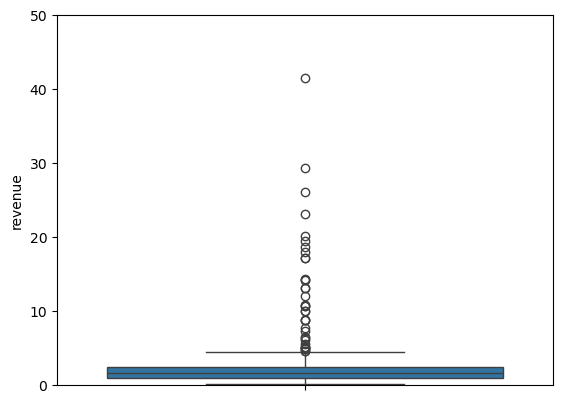

In [564]:
# Посмотрим выбросы
sns.boxplot(df['revenue'])
plt.ylim((0, 50))

<Axes: ylabel='revenue'>

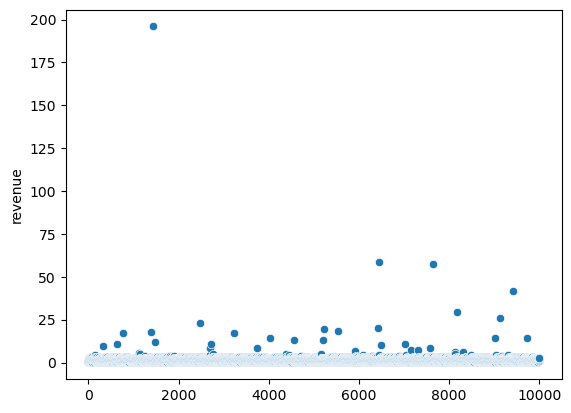

In [565]:
# Выбросы наглядно видны
sns.scatterplot(df['revenue'])

In [566]:
def ejection(col):
    q75 = np.percentile(col, 75)
    q25 = np.percentile(col, 25)
    iqr = q75 - q25
    ejection_h = q75 + iqr * 1.5
    ejection_l = q25 - iqr * 1.5
    ejection_count = len(col[(ejection_l >= col) | (col >= ejection_h)])
    ejection_perc = ejection_count / len(df) * 100

    return ejection_l, ejection_h, ejection_count, ejection_perc

In [567]:
user_rev = df.groupby('user_id')['revenue'].sum()

In [568]:
ejection(user_rev)

(np.float64(-1.6887500000000002), np.float64(6.36125), 238, 2.3800000000000003)

In [569]:
ejection_l, ejection_h, ejection_count, ejection_perc = ejection(user_rev)

In [570]:
filtered_user_idx = user_rev[(ejection_l <= user_rev) & (user_rev <= ejection_h)].index
good_df = df[df['user_id'].isin(filtered_user_idx)]

(0.0, 50.0)

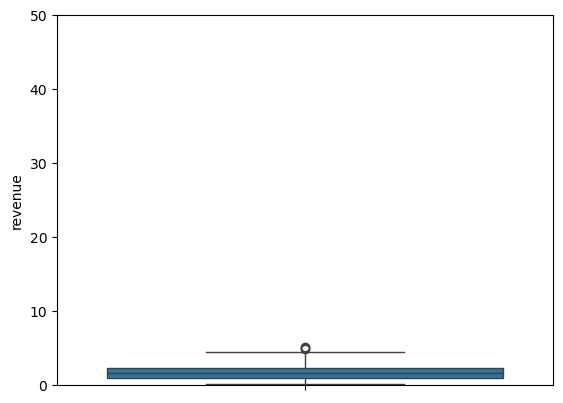

In [571]:
sns.boxplot(good_df['revenue'])
plt.ylim((0, 50))

<Axes: ylabel='revenue'>

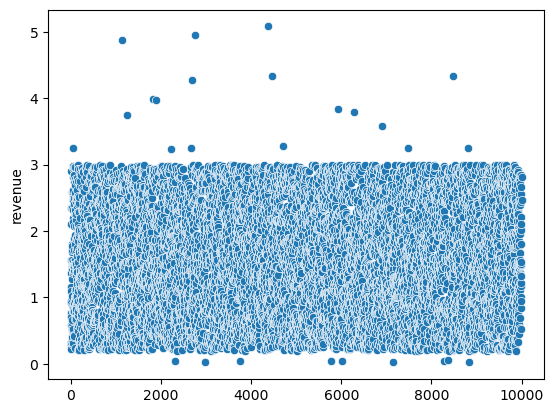

In [572]:
# Проверим вновь выбросы
sns.scatterplot(good_df['revenue'])

In [573]:
# Общее число исключенных заказов
len(df) - len(good_df)

832

### 3. Создайте отчет, содержащий метрики: total_orders total_revenue unique_users ARPU AOV

In [574]:
report_3 = good_df.pivot_table(index='variant_name', aggfunc={'revenue': ['count', 'sum'], 'user_id': 'nunique'}, values=['revenue', 'user_id']).reset_index()
report_3

variant_name revenue          user_id
                 count      sum nunique
0      control    4612  7218.99    3062
1      variant    4556  7188.20    3024

In [575]:
report_3.columns = ['variant_name', 'total_orders', 'total_revenue', 'unique_users']

In [576]:
report_3['ARPU'] = report_3['total_revenue'] / report_3['unique_users']
report_3['AOV'] = report_3['total_revenue'] / report_3['total_orders']

In [577]:
report_3

,variant_name,total_orders,total_revenue,unique_users,ARPU,AOV
0,control,4612,7218.99,3062,2.357606,1.565262
1,variant,4556,7188.20,3024,2.377050,1.577744


### 4. Проверьте гипотезу о равенстве выручки в двух группах

In [429]:
# Так как ARPU является метрикой, имеющей скошенное распределение, то используем тест Манна-Уитни. Для этого подготовим данные
control_rev = good_df.query('variant_name == "control"').groupby('user_id')['revenue'].sum()
variant_rev = good_df.query('variant_name == "variant"').groupby('user_id')['revenue'].sum()

In [583]:
# Нулевая гипотеза: ARPU_control == ARPU_variant
# Альтернативная гипотеза ARPU_control != ARPU_variant
alpha = 0.05

stat, p = st.mannwhitneyu(control_rev, variant_rev)

if p < alpha:
    print(p, 'Следует отвергнуть нулевую гипотезу: ARPU не равны по группам')
else:
    print(p, 'Нет оснований отвергнуть нулевую гипотезу: ARPU равны по группам')

0.1708754532891884 Нет оснований отвергнуть нулевую гипотезу: ARPU равны по группам


### 5. Сформилируйте вывод по отчету и тесту.

### Выводы по отчету:
- Найдено 1541 пользователей, находившихся одновременно в группах control и variant - такого быть не может, поэтому они были переопределены равномерно и в случайном порядке;
- Без учета этих пользователей в группе control 2390 юзеров, а в variant - 2393 (то есть группы примерно равны)
- Исходя из первых двух пунктов распределение пользователей по группам в итоге равномерное, что соответствует классическому A/B тестированию
- Дубликаты найдены 24 штуки, однако их структура такова: За разные заказы один и тот же пользователь заплатил одинаковую сумму. Следовательно, при их удалении мы лишимся части совершенных заказов, что некорректно
- Найдены выбросы на уровне пользователей (то есть были получены суммы со всех заказов, совершенных каждым пользователем и на основе этих данных найдены выбросы - 238 единиц, что составляет ~2.4% от всех пользователей). Из исследуемого датасета были исключены пользователи, совершившие заказ на сумму, относящуюся к выбросам. Таким образом, было исключено 832 заказа
- Метрики 'variant_name', 'total_orders', 'total_revenue', 'unique_users', 'ARPU', 'AOV' -  получены в таблицы report_3. Из-за рандомизации части пользователей, результаты каждый раз могут незначительно отличаться
- При проверки гипотезы, при рандомизации части пользователей, находящихся пока что было зафиксировано только не отвержение нулевой гипотезы с вероятностью ошибки 5%. В данном тесте p-value = 0.17, что больше 0.05. Таким образом, различия между контрольной и тестовой группами по метрике ARPU статистически не значимы. Не раскатываем фичу, которая была предложена тестовой группе в целях повышения данного показателя

In [581]:
report_3;